WITH FUZZY

In [ ]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# =====================
# Load Dataset
# =====================
df = pd.read_csv("/content/Banglore_traffic_Dataset.csv")

# Drop non-numeric columns except target ones
non_numeric = df.select_dtypes(include=['object']).columns
df = df.drop(non_numeric, axis=1, errors="ignore")

# Fill missing values
df = df.ffill()

# =====================
# Define Fuzzy Features
# =====================
def add_fuzzy_features(df, column):
    """Create fuzzy features (Low, Medium, High) for a given column."""
    x = df[column].values
    x_min, x_max = np.min(x), np.max(x)

    # Define fuzzy universe
    universe = np.linspace(x_min, x_max, 100)

    # Membership functions
    low = fuzz.trimf(universe, [x_min, x_min, (x_min + x_max) / 2])
    medium = fuzz.trimf(universe, [x_min, (x_min + x_max) / 2, x_max])
    high = fuzz.trimf(universe, [(x_min + x_max) / 2, x_max, x_max])

    # Calculate membership values for each data point
    df[column + "_Low"] = fuzz.interp_membership(universe, low, x)
    df[column + "_Medium"] = fuzz.interp_membership(universe, medium, x)
    df[column + "_High"] = fuzz.interp_membership(universe, high, x)

    return df

# Add fuzzy features for important columns
if "Traffic Volume" in df.columns:
    df = add_fuzzy_features(df, "Traffic Volume")
if "Travel Time Index" in df.columns:
    df = add_fuzzy_features(df, "Travel Time Index")

# =====================
# Helper: Create Sequences
# =====================
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

# =====================
# Build Dense Model
# =====================
def build_dense_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# =====================
# 1) Travel Time Index - Regression
# =====================
if "Travel Time Index" in df.columns:
    features = df.drop(["Travel Time Index"], axis=1, errors="ignore")
    target = df["Travel Time Index"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_seq, y_seq = create_sequences(X_scaled, target.values)

    # Flatten sequence for Dense model (2D input)
    X_seq_flat = X_seq.reshape(X_seq.shape[0], -1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_seq_flat, y_seq, test_size=0.2, shuffle=False
    )

    model = build_dense_model(X_train.shape[1])
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    print("\n🔹 Travel Time Index (Regression with Fuzzy + Dense NN):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

# =====================
# 2) Traffic Volume - Regression
# =====================
if "Traffic Volume" in df.columns:
    features = df.drop(["Traffic Volume"], axis=1, errors="ignore")
    target = df["Traffic Volume"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_seq, y_seq = create_sequences(X_scaled, target.values)

    # Flatten sequence for Dense model
    X_seq_flat = X_seq.reshape(X_seq.shape[0], -1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_seq_flat, y_seq, test_size=0.2, shuffle=False
    )

    model = build_dense_model(X_train.shape[1])
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    print("\n🔹 Traffic Volume (Regression with Fuzzy + Dense NN):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3198
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0896
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0802
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0707
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0627
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0548
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0498
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0428
Epoch 9/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0390
Epoch 10/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0360
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

🔹 Travel Time Index (Regression with Fuzzy + Dense NN):
MSE: 0.02715595378210347
RMSE: 0.1647906362088073
MAE: 0.14656126370893746
R²: -0.010033596161701963
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 982266368.0000
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 274730112.0000
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 185428208.0000
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 182095120.0000
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 183442688.0000
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 186236640.0000
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 189893184.0000
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 184572176.0000
Epoch 9/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 186972368.0000
Epoch 10/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 181129584.0000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🔹 Traffic Volume (Regression with Fuzzy + Dense NN):
MSE: 165611248.0
RMSE: 12869.00338021558
MAE: 10482.04296875
R²: -0.004141807556152344


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Congestion level: 94.82%

Confusion Matrix:
 [[  69   32    0]
 [  22  596   60]
 [   0   25 1877]]

Classification Report:
               precision    recall  f1-score   support

         Low       0.76      0.68      0.72       101
      Medium       0.91      0.88      0.90       678
        High       0.97      0.99      0.98      1902

    accuracy                           0.95      2681
   macro avg       0.88      0.85      0.86      2681
weighted avg       0.95      0.95      0.95      2681



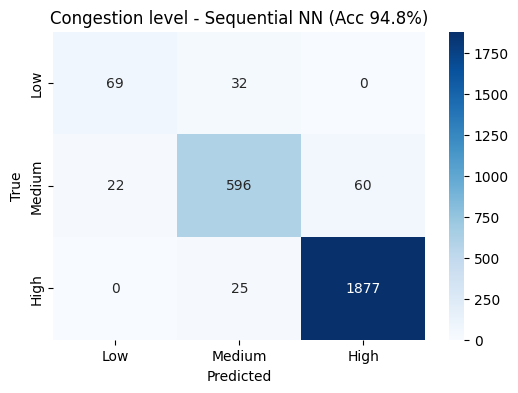

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# =====================
# Load dataset
# =====================
# df = pd.read_csv("your_dataset.csv")

# Target
bins_true = [0, 30, 70, 100]
labels = ["Low", "Medium", "High"]
y_true = pd.cut(df["Congestion Level"], bins=bins_true, labels=labels, include_lowest=True)

# =====================
# Example fuzzy features based on input traffic column (say 'Vehicle Count')
# =====================
def fuzzy_low(x):
    if x <= 20: return 1
    elif 20 < x <= 40: return (40 - x) / 20
    else: return 0

def fuzzy_medium(x):
    if 20 < x <= 40: return (x - 20) / 20
    elif 40 < x <= 60: return (60 - x) / 20
    else: return 0

def fuzzy_high(x):
    if x >= 60: return 1
    elif 40 < x < 60: return (x - 40) / 20
    else: return 0

# Add fuzzy features using Vehicle Count (or another numeric column you have)
X = df.drop(columns=["Congestion Level"]).copy()
if "Vehicle Count" in X.columns:
    X["fuzzy_low"] = df["Vehicle Count"].apply(fuzzy_low)
    X["fuzzy_medium"] = df["Vehicle Count"].apply(fuzzy_medium)
    X["fuzzy_high"] = df["Vehicle Count"].apply(fuzzy_high)

# Keep numeric
X = X.select_dtypes(include=[np.number])

# Normalize
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y_true)

# =====================
# Train/Test Split
# =====================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# =====================
# Build Sequential NN
# =====================
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation="relu"),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train
model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0, validation_split=0.2)

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred_labels = le.inverse_transform(y_pred)

# =====================
# Evaluation
# =====================
acc = accuracy_score(le.inverse_transform(y_test), y_pred_labels)
cm = confusion_matrix(le.inverse_transform(y_test), y_pred_labels, labels=labels)

print(f"Congestion level: {acc*100:.2f}%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(le.inverse_transform(y_test), y_pred_labels, labels=labels))

# =====================
# Plot CM
# =====================
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Congestion level - Sequential NN (Acc {acc*100:.1f}%)")
plt.show()


WITHOUT FUZZY

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# =====================
# Load Dataset
# =====================
df = pd.read_csv("/content/Banglore_traffic_Dataset.csv")

# Drop non-numeric columns except target ones
non_numeric = df.select_dtypes(include=['object']).columns
df = df.drop(non_numeric, axis=1, errors="ignore")

# Fill missing values
df = df.ffill()

# =====================
# 1) Travel Time Index - Regression
# =====================
if "Travel Time Index" in df.columns:
    features = df.drop(["Travel Time Index"], axis=1, errors="ignore")
    target = df["Travel Time Index"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, target.values, test_size=0.2, shuffle=True)

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1)  # Regression output
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    print("\n🔹 Travel Time Index (Regression):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

# =====================
# 2) Traffic Volume - Regression
# =====================
if "Traffic Volume" in df.columns:
    features = df.drop(["Traffic Volume"], axis=1, errors="ignore")
    target = df["Traffic Volume"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, target.values, test_size=0.2, shuffle=True)

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1)  # Regression output
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    print("\n🔹 Traffic Volume (Regression):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

# =====================
# 3) Traffic Category - Classification
# =====================
if "Traffic Category" in df.columns:
    features = df.drop(["Traffic Category"], axis=1, errors="ignore")
    target = df["Traffic Category"]

    le = LabelEncoder()
    y_encoded = le.fit_transform(target)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, shuffle=True)

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(len(le.classes_), activation='softmax')  # Classification output
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("\n🔹 Traffic Category (Classification):")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2616
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0240
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0173
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0154
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0132
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0121
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0109
Epoch 9/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0105
Epoch 10/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0102
Epoch 11/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0105
Epoch 12/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0099
Epoch 13/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0090
Epoch 14/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0094
Epoch 15/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0088


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1024440000.0000
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 809210880.0000
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 266269776.0000
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 105434616.0000
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 96887096.0000
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 88844704.0000
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 81167808.0000
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 70006360.0000
Epoch 9/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 66347516.0000
Epoch 10/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 58580280.0000
Epoch 11/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 52440924.0000
Epoch 12/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47389092.0000
Epoch 13/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 43585100.0000
Epoch 14/20
224/224 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# =====================
# 3) Congestion Level - Classification (SNN: Low/Medium/High)
# =====================
if "Congestion Level" in df.columns:
    # Force 3 bins between min and max values
    df["Congestion_Class"] = pd.cut(
        df["Congestion Level"],
        bins=3,
        labels=["Low", "Medium", "High"],
        include_lowest=True
    )

    features = df.drop(
        ["Travel Time Index", "Congestion Level", "Traffic Volume", "Congestion_Class"],
        axis=1, errors="ignore"
    )
    target = df["Congestion_Class"]

    le = LabelEncoder()
    y_encoded = le.fit_transform(target)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    # For SNN (no sequences needed, use flat data)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=0.2, shuffle=True, random_state=42
    )

    # Build Sequential Neural Network
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(len(le.classes_), activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Early stopping
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[es],
        verbose=1
    )

    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("\n🔹 Congestion Level (Classification with SNN):")
    print("Classes:", list(le.classes_))  # ['Low', 'Medium', 'High']
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7130 - loss: 0.6955 - val_accuracy: 0.9035 - val_loss: 0.2506
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8655 - loss: 0.2900 - val_accuracy: 0.9042 - val_loss: 0.2176
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8930 - loss: 0.2423 - val_accuracy: 0.9280 - val_loss: 0.1677
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9106 - loss: 0.2063 - val_accuracy: 0.9420 - val_loss: 0.1481
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9219 - loss: 0.1893 - val_accuracy: 0.9371 - val_loss: 0.1503
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9195 - loss: 0.1855 - val_accuracy: 0.9371 - val_loss: 0.1415
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9189 - loss: 0.1815 - val_accuracy: 0.9357 - val_loss: 0.1445
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9322 - loss: 0.1730 - val_accuracy: 0.9371 - val

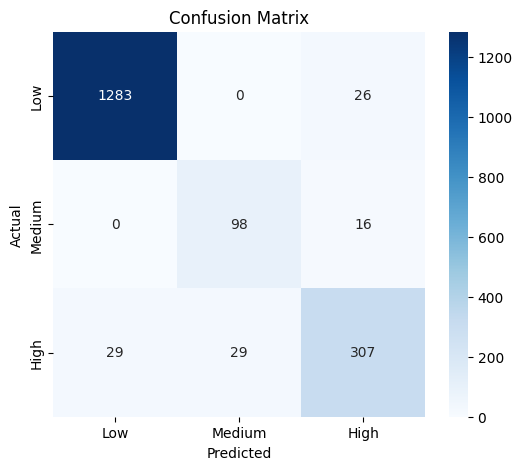

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your confusion matrix
cm = np.array([[1283,    0,   26],
               [   0,   98,   16],
               [  29,   29,  307]])

labels = ["Low", "Medium", "High"]

# ---------- Raw Confusion Matrix ----------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

